<a href="https://colab.research.google.com/github/Kirieshka124/ml_basics/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9611_%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%B8_%D1%81%D0%B5%D0%B3%D0%BC%D0%B5%D0%BD%D1%82%D0%B0%D1%86%D0%B8%D1%8F_%D0%BA%D0%BB%D0%B8%D0%B5%D0%BD%D1%82%D0%BE%D0%B2_%D1%81_%D0%BF%D0%BE%D0%BC%D0%BE%D1%89%D1%8C%D1%8E_%D0%B0%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC%D0%BE%D0%B2_%D0%BA%D0%BB%D0%B0%D1%81%D1%82%D0%B5%D1%80%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №11. Анализ и сегментация клиентов с помощью алгоритмов кластеризации**

### **Цель работы:**

Разработать систему сегментации клиентов для розничной компании с использованием алгоритмов кластеризации. Это позволит компании лучше понимать своих клиентов, персонализировать маркетинговые кампании и оптимизировать бизнес-процессы.

### **Введение:**

Розничные компании сталкиваются с большим объемом данных о своих клиентах, включая историю покупок, демографическую информацию и поведенческие характеристики. Однако без должного анализа эти данные остаются неиспользованными. Сегментация клиентов позволяет выделить группы с общими характеристиками, чтобы более эффективно таргетировать предложения и улучшить удовлетворенность клиентов.



### **Задачи:**

1. **Сбор и анализ данных о клиентах.**
2. **Предобработка и подготовка данных для моделирования.**
3. **Применение различных алгоритмов кластеризации для сегментации клиентов.**
4. **Оценка качества кластеризации с использованием внутренних и внешних метрик.**
5. **Интерпретация и визуализация результатов.**
6. **Формирование рекомендаций для бизнес-стратегии компании на основе полученных сегментов.**



### **Пошаговое описание рабочего процесса (пайплайна):**

#### **Шаг 1: Сбор и анализ данных**

**1.1. Выбор набора данных:**

- Используйте датасет "Online Retail II" из [UCI Machine Learning Repository](https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci) или [другой открытый набор данных](https://archive.ics.uci.edu/datasets?Task=Clustering&skip=0&take=10&sort=desc&orderBy=NumHits&search=&Area=Business), содержащий информацию о транзакциях клиентов.
- Данные должны включать:
  - Идентификаторы клиентов.
  - Информацию о покупках (товары, количество, стоимость).
  - Дату и время транзакций.
  - Демографические данные (если доступны): возраст, пол, локация и т.д.


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objs as go
import seaborn as sns
from IPython.display import HTML, display
from mpl_toolkits.mplot3d import Axes3D
from plotly.subplots import make_subplots
from sklearn import (cluster, decomposition, ensemble, linear_model, manifold,
                     metrics, mixture, model_selection, pipeline,
                     preprocessing)

warnings.filterwarnings("ignore")

plt.rcParams["patch.force_edgecolor"] = True

In [2]:
import requests
import zipfile
import io
import pandas as pd

url = "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"

response = requests.get(url, verify=False)

with zipfile.ZipFile(io.BytesIO(response.content)) as zfile:
    zfile.extractall()

data = pd.read_excel("online_retail_II.xlsx")  # принимает локальный путь к Excel
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


**1.2. Первичный анализ данных (EDA):**

- Изучите структуру данных и их распределение.
- Определите основные характеристики данных:
  - Общий объем продаж.
  - Частота покупок по клиентам.
  - Распределение выручки по товарам.
- Выявите тенденции и аномалии.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [ ]:
print(f"Общий объем продаж: {data['Quantity'].sum()}")

Общий объем продаж: 5432041


#### **Шаг 2: Предобработка данных**

**2.1. Работа с пропущенными значениями:**

- Проанализируйте наличие пропущенных данных.
- Решите, как справиться с ними:
  - Удаление строк/столбцов с пропущенными значениями.
  - Заполнение пропущенных значений средним, медианой или наиболее частым значением.


In [ ]:
# 2.1
display(data.isnull().sum())
print('Сколько потеряем данных в %, если удалить данные признаки')
display(data.isnull().sum()*100/data.shape[0])

,0
Invoice,0
StockCode,0
Description,2928
Quantity,0
InvoiceDate,0
Price,0
Customer ID,107927
Country,0


Сколько потеряем данных в %, если удалить данные признаки


,0
Invoice,0.000000
StockCode,0.000000
Description,0.557225
Quantity,0.000000
InvoiceDate,0.000000
Price,0.000000
Customer ID,20.539488
Country,0.000000


In [ ]:
data = data.dropna(subset=['Customer ID'])
data.info()
# данные с пропусками в "Description" пока не обрабатываем

<class 'pandas.core.frame.DataFrame'>
Index: 417534 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      417534 non-null  object        
 1   StockCode    417534 non-null  object        
 2   Description  417534 non-null  object        
 3   Quantity     417534 non-null  int64         
 4   InvoiceDate  417534 non-null  datetime64[ns]
 5   Price        417534 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      417534 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 28.7+ MB


In [ ]:
print(f"Количество полностью дублированных записей: {data.duplicated().value_counts()[1]}")
data.drop_duplicates(inplace=True)

Количество полностью дублированных записей: 6771


**2.3. Создание новых признаков:**

- Рассчитайте Recency, Frequency, Monetary Value (RFM-анализ):
  - **Recency (давность):** Время с момента последней покупки.
  - **Frequency (частота):** Количество покупок за определенный период.
  - **Monetary (сумма):** Общая сумма покупок.
- Создайте дополнительные признаки, такие как средний чек, предпочтительные категории товаров и т.д.

In [ ]:
def get_quantity_canceled(data):
    """
    Функция проходит по всем транзакциям-возвратам в рамках каждой группы
    (Customer ID, StockCode) и ищет покупку (или покупки) с более ранней датой
    и подходящим количеством товара. В результате возвращает Series, где
    для каждой «положительной» записи (покупки) указывается, сколько товаров
    вернули позднее.
    """
    # Создаём результирующий столбец, заполненный нулями
    quantity_canceled = pd.Series(0, index=data.index, dtype=int)

    # Разбиваем таблицу на группы по клиенту и коду товара
    grouped = data.groupby(['Customer ID', 'StockCode'], group_keys=False)

    def process_group(df_group):
        # Сортируем текущую группу по дате
        df_group = df_group.sort_values('InvoiceDate')

        # Отбираем положительные (покупки) и отрицательные (возвраты) записи
        positives = df_group[df_group['Quantity'] > 0]
        negatives = df_group[df_group['Quantity'] < 0]

        for neg_idx, neg_row in negatives.iterrows():
            # Ищем те покупки, что идут раньше по дате
            candidates = positives[positives['InvoiceDate'] < neg_row['InvoiceDate']]
            if candidates.empty:
                continue

            # Если ровно одна запись подходит, сразу сохраняем результат
            if len(candidates) == 1:
                quantity_canceled.at[candidates.index[0]] = -neg_row['Quantity']
            else:
                # Несколько возможных покупок: сортируем их в обратном порядке индексов (или дат)
                candidates = candidates.sort_index(ascending=False)
                # Ищем первую, где Quantity >= нужного объёма возврата
                for pos_idx, pos_row in candidates.iterrows():
                    if pos_row['Quantity'] >= -neg_row['Quantity']:
                        quantity_canceled.at[pos_idx] = -neg_row['Quantity']
                        break

        return df_group

    # Применяем функцию к каждой группе
    grouped.apply(process_group)

    return quantity_canceled

# Пример использования
data['QuantityCanceled'] = get_quantity_canceled(data)

In [ ]:
# убираем заказы-возвраты и заказы с отрицательной ценой
data_cleaned = data[data['Quantity'] > 0].copy()
data_cleaned = data_cleaned[data_cleaned['Price'] != 0]

data_cleaned['InvoiceDate'] = pd.to_datetime(data_cleaned['InvoiceDate'])
# Рассчитываем общую стоимость заказа (TotalPrice)
data_cleaned['TotalPrice'] = data_cleaned['Price'] * (
    data_cleaned['Quantity'] - data_cleaned['QuantityCanceled']
)
# Создаём признак даты из времени совершения транзакции
data_cleaned['Date'] = data_cleaned['InvoiceDate'].dt.date

In [ ]:
# Контрольная дата (на один день превышает последнюю дату в данных)
now = pd.to_datetime("2010-12-10")

# Настраиваем агрегацию для RFM-параметров
custom_aggregation = {
    "InvoiceDate": lambda x: (now - x.max()).days,  # Recency
    "Invoice": lambda x: x.nunique(),            # Frequency
    "Price": "sum",                           # Monetary
}

# Формируем RFM-таблицу
rfm_table = (
    data
    .groupby("Customer ID")
    .agg(custom_aggregation)
    .rename(columns={
        "InvoiceDate": "Recency",
        "Invoice": "Frequency",
        "Price": "Monetary",
        "Quantity": "MeanQuantity"
    })
)

# Просматриваем первые строки итоговой таблицы
rfm_table.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,66,15,565.42
12347.0,2,2,162.95
12348.0,73,1,14.39
12349.0,42,4,899.49
12351.0,10,1,49.46


In [ ]:
display(rfm_table.info())
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4383 entries, 12346.0 to 18287.0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    4383 non-null   int64  
 1   Frequency  4383 non-null   int64  
 2   Monetary   4383 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 137.0 KB


None

<class 'pandas.core.frame.DataFrame'>
Index: 400916 entries, 0 to 525460
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Invoice           400916 non-null  object        
 1   StockCode         400916 non-null  object        
 2   Description       400916 non-null  object        
 3   Quantity          400916 non-null  int64         
 4   InvoiceDate       400916 non-null  datetime64[ns]
 5   Price             400916 non-null  float64       
 6   Customer ID       400916 non-null  float64       
 7   Country           400916 non-null  object        
 8   QuantityCanceled  400916 non-null  int64         
 9   TotalPrice        400916 non-null  float64       
 10  Date              400916 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(5)
memory usage: 36.7+ MB



**2.2. Обработка выбросов:**

- Выявите выбросы в данных (например, аномально большие заказы).
- Решите, следует ли их удалить или обработать иным образом.

In [ ]:
import plotly.express as px
from plotly.subplots import make_subplots

# Выбираем столбцы для построения коробчатых диаграмм
columns_to_plot = ["Recency", "Frequency", "Monetary"]

# Создаём коробчатые диаграммы для каждого из выбранных признаков
boxes = [px.box(rfm_table, x=col) for col in columns_to_plot]

# Формируем макет из трёх подположений
fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=("Recency", "Frequency", "Monetary")
)

# Добавляем каждую диаграмму в свой подплот
for i, box_fig in enumerate(boxes):
    fig.add_trace(box_fig.data[0], row=1, col=i+1)

# Настраиваем и выводим итоговую диаграмму
fig.update_layout(showlegend=True)
fig.write_html("boxplot_1.html")
fig.show()

In [ ]:
h_cap_monetary = rfm_table["Monetary"].quantile(0.95)
h_cap_frequency = rfm_table["Frequency"].quantile(0.95)
h_cap_recency = rfm_table["Recency"].quantile(0.95)

# Отбираем выбросы
outliers = rfm_table[
    (rfm_table["Recency"] > h_cap_recency) |
    (rfm_table["Monetary"] > h_cap_monetary) |
    (rfm_table["Frequency"] > h_cap_frequency)
]

rfm_table_cleaned = rfm_table.drop(outliers.index)

# Выводим количество оставшихся записей (клиентов)
print(f"После удаления выбросов осталось {rfm_table_cleaned.shape[0]} клиентов в RFM-таблице.")

После удаления выбросов осталось 3847 клиентов в RFM-таблице.


In [ ]:
import plotly.express as px
from plotly.subplots import make_subplots

# Формируем список диаграмм для выбранных столбцов RFM-таблицы
columns_to_plot = ["Recency", "Frequency", "Monetary"]
boxes = [px.box(rfm_table_cleaned, x=col) for col in columns_to_plot]

# Создаём макет для трёх коробчатых диаграмм
fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=("Recency", "Frequency", "Monetary")
)

# Добавляем каждую коробчатую диаграмму в соответствующее подполе
for i, box_fig in enumerate(boxes):
    fig.add_trace(box_fig.data[0], row=1, col=i+1)

# Настраиваем внешний вид и отображаем результат
fig.update_layout(showlegend=True)
fig.write_html("boxplot_2.html")
fig.show()

**2.4. Нормализация и масштабирование:**

- Примените стандартизацию или нормализацию к числовым признакам для приведения их к единому масштабу.
- Объясните выбор метода масштабирования.

In [ ]:
from sklearn.preprocessing import StandardScaler

features = ['Recency', 'Frequency', 'Monetary']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_table_cleaned[features])

**Обоснование**

1. **Разные единицы измерения и масштабы:**
   - `Recency` измеряется в днях (десятки/сотни),
   - `Frequency` — в количестве заказов (единицы/десятки),
   - `Monetary` — в денежной сумме (сотни/тысячи). Без масштабирования `Monetary` полностью подавит влияние остальных метрик.

3. **Удалены выбросы:**
   На предыдущем этапе мы отсекли аномалии по 95-му перцентилю. `StandardScaler` чувствителен к выбросам, но после их удаления этот недостаток нейтрализован. `MinMaxScaler` сжала бы все значения в диапазон `[0, 1]`, что могло бы исказить структуру кластеров и сделать модель менее устойчивой.

#### **Шаг 3: Применение алгоритмов кластеризации**

**3.1. Выбор алгоритмов:**

- **K-средних (K-Means):** Для разбиения данных на k кластеров на основе эврестического подхода.
- **Иерархическая кластеризация:** Для выявления вложенной структуры кластеров.
- **DBSCAN и OPTICS:** Для обнаружения кластеров произвольной формы и выявления выбросов.



**Ответ**: попробуем применить все алгоритмы ¯\\\_(ツ)_/¯

**3.2. Определение оптимального количества кластеров:**

- Для K-Means и иерархической кластеризации используйте:
  - **Метод локтя (Elbow Method):** Постройте график зависимости суммы квадратов внутрикластерных расстояний от числа кластеров.
  - **Коэффициент силуэта:** Рассчитайте для различных значений k и выберите оптимальное.

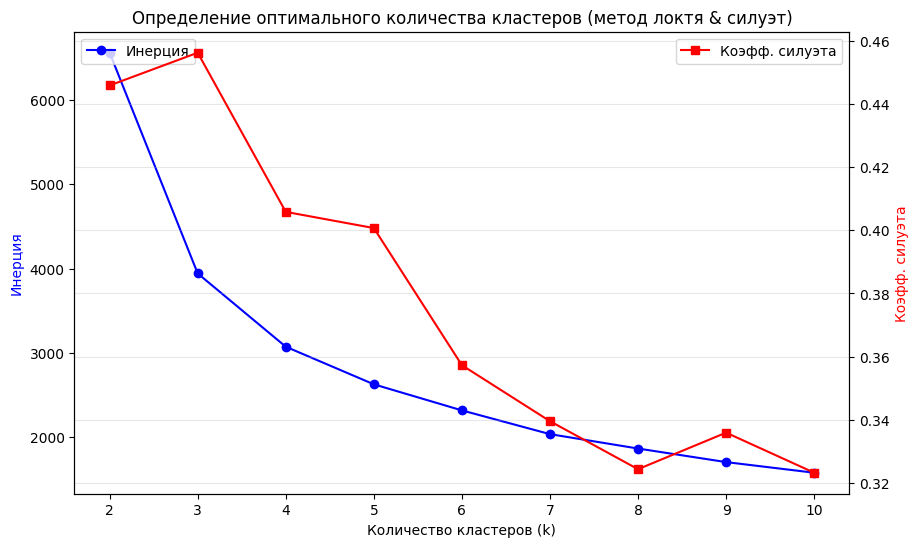

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

wcss = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()
ax1.plot(k_range, wcss, 'b-o', label='Инерция')
ax2.plot(k_range, silhouettes, 'r-s', label='Коэфф. силуэта')
ax1.set_xlabel('Количество кластеров (k)')
ax1.set_ylabel('Инерция', color='b')
ax2.set_ylabel('Коэфф. силуэта', color='r')
plt.title('Определение оптимального количества кластеров (метод локтя & силуэт)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

# на графике видно, что значения убывают после k=3 или k=4, однако коэфф. силуэта достигается максимума на k=3.
# Для дальнейших шагов выберем k = 3.
optimal_k = 3

**3.3. Применение алгоритмов:**

- Запустите каждый алгоритм на подготовленных данных.
- Сохраняйте результаты кластеризации для последующего анализа.

In [ ]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans1 = KMeans(n_clusters=optimal_k+1, random_state=42, n_init=10)
kmeans2 = KMeans(n_clusters=optimal_k+2, random_state=42, n_init=10)
rfm_table_cleaned['cluster_km'] = kmeans.fit_predict(X_scaled)
rfm_table_cleaned['cluster_km1'] = kmeans1.fit_predict(X_scaled)
rfm_table_cleaned['cluster_km2'] = kmeans2.fit_predict(X_scaled)

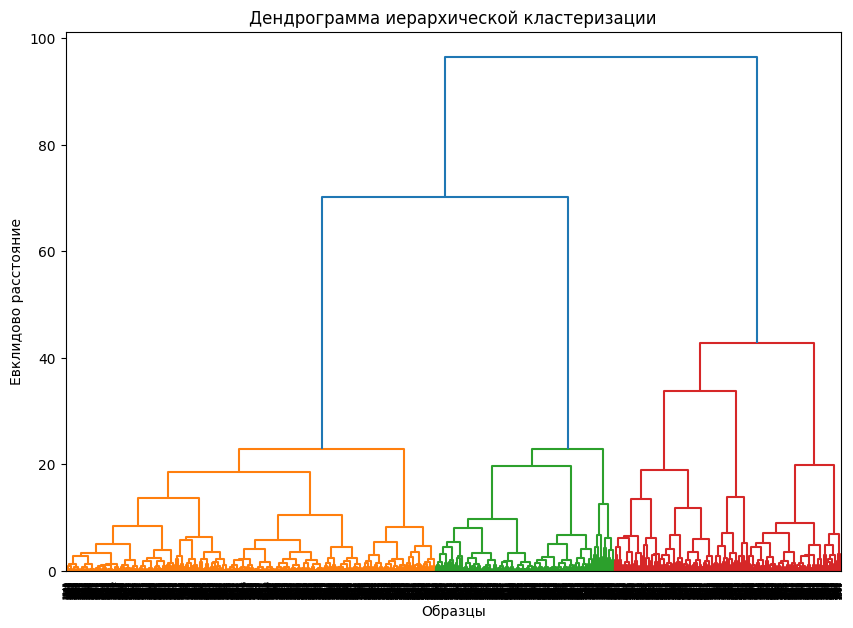

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Вычисление матрицы связей для построения дендрограммы
linked = linkage(X_scaled, method='ward')

# Построение дендрограммы
plt.figure(figsize=(10, 7))
dendrogram(linked,
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Дендрограмма иерархической кластеризации')
plt.xlabel('Образцы')
plt.ylabel('Евклидово расстояние')
plt.show()

# Применение иерархической кластеризации с исправлением параметра
hc = AgglomerativeClustering(n_clusters=optimal_k, metric='euclidean', linkage='ward')
hc1 = AgglomerativeClustering(n_clusters=optimal_k+1, metric='euclidean', linkage='ward')
hc2 = AgglomerativeClustering(n_clusters=optimal_k+2, metric='euclidean', linkage='ward')
rfm_table_cleaned['cluster_hc'] = hc.fit_predict(X_scaled)
rfm_table_cleaned['cluster_hc1'] = hc1.fit_predict(X_scaled)
rfm_table_cleaned['cluster_hc2'] = hc2.fit_predict(X_scaled)

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.62, min_samples=3)
dbscan1 = DBSCAN(eps=0.52, min_samples=3)
dbscan2 = DBSCAN(eps=0.45, min_samples=3)
rfm_table_cleaned['cluster_db'] = dbscan.fit_predict(X_scaled)
rfm_table_cleaned['cluster_db1'] = dbscan1.fit_predict(X_scaled)
rfm_table_cleaned['cluster_db2'] = dbscan2.fit_predict(X_scaled)

#### **Шаг 4: Оценка качества кластеризации**

**4.1. Внутренние метрики:**

- **Коэффициент силуэта:** Оцените, насколько хорошо объекты расположены внутри кластеров.
- **Индекс Дэвиса-Болдина:** Оцените уровень разделимости кластеров.
- **Индекс Калинского-Харабаза:** Оцените соотношение межкластерной дисперсии к внутрикластерной.



In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sil_km = silhouette_score(X_scaled, rfm_table_cleaned['cluster_km'])
db_km = davies_bouldin_score(X_scaled, rfm_table_cleaned['cluster_km'])
ch_km = calinski_harabasz_score(X_scaled, rfm_table_cleaned['cluster_km'])
sil_km1 = silhouette_score(X_scaled, rfm_table_cleaned['cluster_km1'])
db_km1 = davies_bouldin_score(X_scaled, rfm_table_cleaned['cluster_km1'])
ch_km1 = calinski_harabasz_score(X_scaled, rfm_table_cleaned['cluster_km1'])
sil_km2 = silhouette_score(X_scaled, rfm_table_cleaned['cluster_km2'])
db_km2 = davies_bouldin_score(X_scaled, rfm_table_cleaned['cluster_km2'])
ch_km2 = calinski_harabasz_score(X_scaled, rfm_table_cleaned['cluster_km2'])

In [ ]:
sil_db = silhouette_score(X_scaled, rfm_table_cleaned['cluster_db'])
db_db = davies_bouldin_score(X_scaled, rfm_table_cleaned['cluster_db'])
ch_db = calinski_harabasz_score(X_scaled, rfm_table_cleaned['cluster_db'])
sil_db1 = silhouette_score(X_scaled, rfm_table_cleaned['cluster_db1'])
db_db1 = davies_bouldin_score(X_scaled, rfm_table_cleaned['cluster_db1'])
ch_db1 = calinski_harabasz_score(X_scaled, rfm_table_cleaned['cluster_db1'])
sil_db2 = silhouette_score(X_scaled, rfm_table_cleaned['cluster_db2'])
db_db2 = davies_bouldin_score(X_scaled, rfm_table_cleaned['cluster_db2'])
ch_db2 = calinski_harabasz_score(X_scaled, rfm_table_cleaned['cluster_db2'])

In [ ]:
sil_hc = silhouette_score(X_scaled, rfm_table_cleaned['cluster_hc'])
db_hc = davies_bouldin_score(X_scaled, rfm_table_cleaned['cluster_hc'])
ch_hc = calinski_harabasz_score(X_scaled, rfm_table_cleaned['cluster_hc'])
sil_hc1 = silhouette_score(X_scaled, rfm_table_cleaned['cluster_hc1'])
db_hc1 = davies_bouldin_score(X_scaled, rfm_table_cleaned['cluster_hc1'])
ch_hc1 = calinski_harabasz_score(X_scaled, rfm_table_cleaned['cluster_hc1'])
sil_hc2 = silhouette_score(X_scaled, rfm_table_cleaned['cluster_hc2'])
db_hc2 = davies_bouldin_score(X_scaled, rfm_table_cleaned['cluster_hc2'])
ch_hc2 = calinski_harabasz_score(X_scaled, rfm_table_cleaned['cluster_hc2'])

**4.2. Внешние метрики (если доступны истинные метки):**

- **Adjusted Rand Index (ARI):** Сравните полученные кластеры с известными категориями клиентов.
- **Normalized Mutual Information (NMI):** Измерьте общую информацию между распределениями.

***истинных меток нет***

**4.3. Сравнение алгоритмов:**

- Составьте таблицу со значениями метрик для каждого алгоритма.
- Определите, какой алгоритм показал наилучшие результаты и почему.

In [ ]:
cluster_results = {}
cluster_results['KMeans'] = [sil_km, db_km, ch_km]
cluster_results['KMeans1'] = [sil_km1, db_km1, ch_km1]
cluster_results['KMeans2'] = [sil_km2, db_km2, ch_km2]
cluster_results['Agglomerative'] = [sil_hc, db_hc, ch_hc]
cluster_results['Agglomerative1'] = [sil_hc1, db_hc1, ch_hc1]
cluster_results['Agglomerative2'] = [sil_hc2, db_hc2, ch_hc2]
cluster_results['DBSCAN'] = [sil_db, db_db, ch_db]
cluster_results['DBSCAN1'] = [sil_db1, db_db1, ch_db1]
cluster_results['DBSCAN2'] = [sil_db2, db_db2, ch_db2]
clust_res = pd.DataFrame.from_dict(cluster_results, orient='index', columns=['Силуэт', 'Дэвис-Болдин', 'Калински-Харабас'])
clust_res

,Силуэт,Дэвис-Болдин,Калински-Харабас
KMeans,0.456138,0.794696,3705.818691
KMeans1,0.405792,0.935017,3532.918454
KMeans2,0.400670,0.955637,3263.167586
Agglomerative,0.411490,0.858143,3077.129486
Agglomerative1,0.381016,1.000122,2913.392439
Agglomerative2,0.393535,0.968822,2793.372393
DBSCAN,0.411641,1.382711,35.112541
DBSCAN1,0.170096,1.724631,28.596341
DBSCAN2,0.136409,1.595105,25.948936


#### **Шаг 5: Интерпретация и визуализация результатов**

**5.1. Визуализация кластеров:**

- **Снижение размерности:** Примените PCA или t-SNE или UMAP для отображения данных в 2D или 3D пространстве.



In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)
rfm_table_cleaned['PC1'] = principal_components[:, 0]
rfm_table_cleaned['PC2'] = principal_components[:, 1]

- **Постройте графики:**
  - Рассеивания с цветовой кодировкой кластеров.
  - Дендрограммы для иерархической кластеризации.


In [ ]:
fig = px.scatter(rfm_table_cleaned, x='PC1', y='PC2', color='cluster_km',
                 title='Визуализация кластеров в пространстве PCA (K-Means)',
                 labels={'PC1': 'Главная компонента 1', 'PC2': 'Главная компонента 2'},
                 color_continuous_scale='Viridis')
fig.update_traces(marker=dict(size=8, opacity=0.8))
fig.show()

In [ ]:
fig = px.scatter(rfm_table_cleaned, x='PC1', y='PC2', color='cluster_km1',
                 title='Визуализация кластеров в пространстве PCA (K-Means)',
                 labels={'PC1': 'Главная компонента 1', 'PC2': 'Главная компонента 2'},
                 color_continuous_scale='Viridis')
fig.update_traces(marker=dict(size=8, opacity=0.8))
fig.show()

In [ ]:
fig = px.scatter(rfm_table_cleaned, x='PC1', y='PC2', color='cluster_km2',
                 title='Визуализация кластеров в пространстве PCA (K-Means)',
                 labels={'PC1': 'Главная компонента 1', 'PC2': 'Главная компонента 2'},
                 color_continuous_scale='Viridis')
fig.update_traces(marker=dict(size=8, opacity=0.8))
fig.show()

In [ ]:
import plotly.express as px

# Создаём метки кластеров для каждой строки
labels = pd.Series(kmeans.labels_.astype("str"), index=rfm_table_cleaned.index)

fig = px.scatter_3d(
    rfm_table_cleaned,
    x="Recency",
    y="Frequency",
    z="Monetary",
    color=labels.astype("str"),
    title="Распределение клиентов по кластерам (KMeans)"
)
fig.show()

In [ ]:
labels = pd.Series(kmeans1.labels_.astype("str"), index=rfm_table_cleaned.index)

fig = px.scatter_3d(
    rfm_table_cleaned,
    x="Recency",
    y="Frequency",
    z="Monetary",
    color=labels.astype("str"),
    title="Распределение клиентов по кластерам (KMeans)"
)
fig.show()

In [ ]:
# Создаём метки кластеров для каждой строки
labels = pd.Series(kmeans2.labels_.astype("str"), index=rfm_table_cleaned.index)

fig = px.scatter_3d(
    rfm_table_cleaned,
    x="Recency",
    y="Frequency",
    z="Monetary",
    color=labels.astype("str"),
    title="Распределение клиентов по кластерам (KMeans)"
)
fig.show()

In [ ]:
# Создаём метки кластеров для каждой строки
labels = pd.Series(dbscan.labels_.astype("str"), index=rfm_table_cleaned.index)

fig = px.scatter_3d(
    rfm_table_cleaned,
    x="Recency",
    y="Frequency",
    z="Monetary",
    color=labels.astype("str"),
    title="Распределение клиентов по кластерам (DBSCAN)"
)
fig.show()

In [ ]:
# Создаём метки кластеров для каждой строки
labels = pd.Series(dbscan1.labels_.astype("str"), index=rfm_table_cleaned.index)

fig = px.scatter_3d(
    rfm_table_cleaned,
    x="Recency",
    y="Frequency",
    z="Monetary",
    color=labels.astype("str"),
    title="Распределение клиентов по кластерам (DBSCAN)"
)
fig.show()

In [ ]:
# Создаём метки кластеров для каждой строки
labels = pd.Series(dbscan2.labels_.astype("str"), index=rfm_table_cleaned.index)

fig = px.scatter_3d(
    rfm_table_cleaned,
    x="Recency",
    y="Frequency",
    z="Monetary",
    color=labels.astype("str"),
    title="Распределение клиентов по кластерам (DBSCAN)"
)
fig.show()

In [ ]:
labels = pd.Series(hc.labels_.astype("str"), index=rfm_table_cleaned.index)

fig = px.scatter_3d(
    rfm_table_cleaned,
    x="Recency",
    y="Frequency",
    z="Monetary",
    color=labels.astype("str"),
    title="Распределение клиентов по кластерам (Agglomerative)"
)
fig.show()

In [ ]:
labels = pd.Series(hc1.labels_.astype("str"), index=rfm_table_cleaned.index)

fig = px.scatter_3d(
    rfm_table_cleaned,
    x="Recency",
    y="Frequency",
    z="Monetary",
    color=labels.astype("str"),
    title="Распределение клиентов по кластерам (Agglomerative)"
)
fig.show()

In [ ]:
labels = pd.Series(hc2.labels_.astype("str"), index=rfm_table_cleaned.index)

fig = px.scatter_3d(
    rfm_table_cleaned,
    x="Recency",
    y="Frequency",
    z="Monetary",
    color=labels.astype("str"),
    title="Распределение клиентов по кластерам (Agglomerative)"
)
fig.show()

- **Визуализация признаков:**
  - Постройте боксплоты, гистограммы или тепловые карты для сравнения признаков между кластерами.

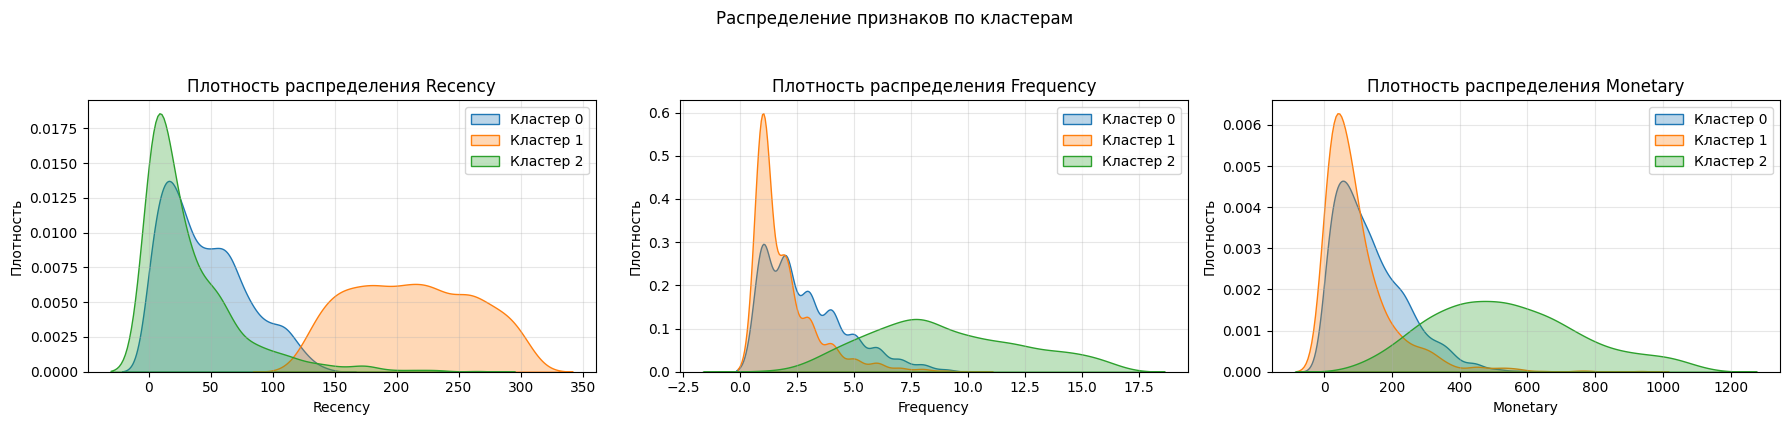

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, feature in enumerate(features):
    for cluster in sorted(rfm_table_cleaned['cluster_km'].unique()):
        subset = rfm_table_cleaned[rfm_table_cleaned['cluster_km'] == cluster]
        sns.kdeplot(data=subset, x=feature, ax=axes[i], label=f'Кластер {cluster}', fill=True, alpha=0.3)
    axes[i].set_title(f'Плотность распределения {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Плотность')
    axes[i].legend()
    axes[i].grid(alpha=0.3)
plt.suptitle('Распределение признаков по кластерам', y=1.05)
plt.tight_layout()
plt.show()

**5.2. Описание сегментов:**

- Для каждого кластера опишите характерные черты:
  - Средние значения признаков.
  - Поведенческие особенности (например, частота покупок, средний чек).
  - Демографические характеристики (если доступны).
- Присвойте сегментам осмысленные названия (например, "Лояльные клиенты", "Покупатели со сниженной активностью", "Большие транзакции").

**Ответ**:

- Кластер 0 - **частые клиенты**: клиенты, покупающие часто (малое значение `Recency`), достаточно мало (малое значение `Frequency`) и дешево (малое значение `Monetary`)

- Кластер 1 - **редкие/новые клиенты**: клиенты, покупающие очень редко (большое значение `Recency`), мало (малое значение `Frequency`) и дешево (малое значение `Monetary`)

- Кластер 2 - **лояльные клиенты**: клиенты, покупающие чаще (малое значение `Recency`) и больше (большое значение `Frequency`) остальных, и тратящие деньги больше (большое значение `Monetary`)

#### **Шаг 6: Формирование бизнес-рекомендаций**

**6.1. Анализ потребностей каждого сегмента:**

- Определите потребности и предпочтения клиентов в каждом сегменте.
- Выявите возможности для увеличения продаж и улучшения сервиса.



**Ответ**:

**Кластер 0 — «Частые клиенты»** (низкие R, F, M)

*Потребности:*
- Быстрый доступ к товарам повседневного спроса, удобство оформления, оперативная доставка.
- Небольшие, но регулярные покупки: важны акции, подписки, кэшбэк.

*Возможности:*
- Стимулировать переход в «лояльных» клиентов через программу накопительных баллов.
- Реферальные программы (приведи друга - бонусы обоим).
---
**Кластер 1 — «Редкие/новые клиенты»** (высокий R, низкие F, M)

*Потребности:*
- Знакомство с брендом, низкий порог входа, доверие к качеству.
- Мотивация на повторную покупку (персональные скидки, приветственные бонусы).

*Возможности:*
- Уведомления через email/push-уведомления с персональными предложениями.
---
**Кластер 2 — «Лояльные клиенты»** (низкий R, высокие F, M)

*Потребности:*
- Признание ценности, эксклюзивный сервис, ранний доступ к новинкам.
- Персонализация: индивидуальные подборки, персональный менеджер.

*Возможности:*
- Удержание через VIP-программы, приглашения на закрытые распродажи.


**6.2. Разработка стратегий для каждого сегмента:**

- **Маркетинговые кампании:**
  - Персонализированные предложения.
  - Программы лояльности для удержания ценных клиентов.
- **Оптимизация продуктов:**
  - Расширение ассортимента для популярных сегментов.
  - Фокус на продуктах, интересных конкретным сегментам.


**Ответ**:

| Сегмент | Маркетинговые кампании | Оптимизация продуктов |
|---------|----------------------|---------------------|
| **Кластер 0** (Частые) |Реферальная программа «приведи друга»<br> Накопительные скидки за серию заказов | Бандлы «часто покупают вместе»<br>Мини-форматы товаров по сниженной цене<br>Упрощённый повтор заказа в 1 клик |
| **Кластер 1** (Редкие/новые) | Приветственная скидка 10-15% на второй заказ<br>Триггерные письма «мы скучаем» через 30/60/90 дней| Стартовые наборы для знакомства с ассортиментом<br>Персональные рекомендации на основе первого заказа|
| **Кластер 2** (Лояльные) | VIP-поддержка<br>Ранний доступ к распродажам и новинкам<br>Эксклюзивные подарки за лояльность | Премиум-линейки товаров, лимитированные коллекции<br>Индивидуальные подборки на основе истории покупок|

**6.3. Оценка потенциального влияния:**

- Оцените, как предложенные стратегии могут повысить выручку, удовлетворенность клиентов и другие ключевые показатели.

**Ответ**:

| Что получим | Как это работает |
|-------------|---------------|
| **Клиенты чувствуют заботу** | Персонализация и удобство вызывают больше доверия, что приводит к большему числу повторных покупок |
| **Меньше «потерянных» клиентов** | Своевременные напоминания и бонусы заставляют людей возвращаются, а не уходить к конкурентам |
| **Растёт ценность каждого клиента** | Программы лояльности, в которых находятся клиенты, позволяют им покупать чаще и дороже |
| **Сарафанное радио** | Довольные клиенты (особенно из кластера 0 и 2) рекомендуют нас друзьям, откуда появляются новые клиенты без затрат на рекламу |


#### **Шаг 7: Документирование и презентация результатов**

**7.1. Подготовка отчета:**

- **Введение:**
  - Описание цели работы и её значимости для бизнеса.
- **Методология:**
  - Подробное описание проведенных шагов.
- **Результаты:**
  - Представление метрик оценки и визуализаций.
  - Описание сегментов клиентов.
- **Обсуждение:**
  - Анализ полученных результатов.
  - Сравнение алгоритмов и обоснование выбора.
- **Рекомендации:**
  - Предложения по внедрению результатов в бизнес-процессы.
- **Заключение:**
  - Выводы о проделанной работе и её значимости.

**7.2. Презентация:**

- Подготовьте слайды для представления ключевых моментов работы.
- Используйте визуализации для иллюстрации результатов.



# **Отчет**

- **Введение:**
  - Розничные компании сталкиваются с большим объемом данных о своих клиентах, включая историю покупок, демографическую информацию и поведенческие характеристики. Однако без должного анализа эти данные остаются неиспользованными. Сегментация клиентов позволяет выделить группы с общими характеристиками, чтобы более эффективно таргетировать предложения и улучшить удовлетворенность клиентов.
  - Цель работы: Разработать систему сегментации клиентов для розничной компании с использованием алгоритмов кластеризации. Это позволит компании лучше понимать своих клиентов, персонализировать маркетинговые кампании и оптимизировать бизнес-процессы.
- **Методология:**
  1. **Сбор и анализ данных о клиентах** – загрузка датасета “Online Retail II”
  2. **Предобработка и подготовка данных для моделирования** – предобработка данных с помощью pandas
  3. **Применение различных алгоритмов кластеризации для сегментации клиентов** – применение из scikit-learn алгоритмов K-Means, DBSCAN, иерархической кластеризации
  4. **Оценка качества кластеризации с использованием внутренних метрик** – оценка с помощью Коэффициента силуэта, индекса Дэвиса-Болдина, индекса Калинского-Харабаза (метрики из scikit-learn)
  5. **Интерпретация и визуализация результатов** – визуализация полученных кластеров с помощью matplotlib, plotly.express, seaborn; выделение полученных кластеров
  6. **Формирование рекомендаций для бизнес-стратегии компании на основе полученных сегментов** – создание рекомендаций на основе полученных результатов, разработка стратегий для каждого сегмента, анализ потребностей каждого из них
- **Результаты:**
  - см. пункт 4.3 (оценки алгоритмов при 3/4/5 кластерах и DBSCAN при разных значениях eps) и 5.1 (визуализация результатов)
  - Наилучшие результаты наблюдались при k=3 (K-Means), были выделены кластеры лояльных; редких/новых; частых клиентов
- **Обсуждение:**
  - Наилучшие результаты как и в визуализации, так и по метрикам, показал алгоритм K-Means.
  - DBSCAN хоть и закинул всё под один кластер (при k=3), но помог выявить вероятные шумы в данных.
  - Иерархическая кластеризация практически схожа с K-Means, но уступает в эффективности по полученным результатам
- **Рекомендации:**
  | Сегмент | Потребности | Возможности| Оптимизация |
|---------|-------------|--------|---------------------|
| **Кластер 0** (Частые) | Быстрый доступ к товарам повседневного спроса<br>Удобство оформления, оперативная доставка<br>Небольшие, но регулярные покупки: важны акции, подписки, кэшбэк | Стимулировать переход в «лояльных» клиентов через программу накопительных баллов.<br>Реферальные программы (приведи друга - бонусы обоим).| Бандлы «часто покупают вместе»<br>Мини-форматы товаров по сниженной цене<br>Упрощённый повтор заказа в 1 клик|
| **Кластер 1** (Редкие/новые) | Знакомство с брендом, низкий порог входа, доверие к качеству<br>Мотивация на повторную покупку (персональные скидки, приветственные бонусы)| Уведомления через email/push-уведомления с персональными предложениями| Стартовые наборы для знакомства с ассортиментом<br>Персональные рекомендации на основе первого заказа|
| **Кластер 2** (Лояльные) | Признание ценности, эксклюзивный сервис, ранний доступ к новинкам<br>Персонализация: индивидуальные подборки, персональный менеджер| Удержание через VIP-программы, приглашения на закрытые распродажи| Премиум-линейки товаров, лимитированные коллекции<br>Индивидуальные подборки на основе истории покупок |
- **Заключение:**
  -  Проделанная работа позволила использовать данные, которые оставались у компаний незатронутыми, в целях улучшения эффективности продаж и повышения удовлетворенности клиентов. Можно и дальше продолжить поиск кластеров, однако данного числа уже достаточно для небольшого прироста эффективности

